<a href="https://colab.research.google.com/github/sri-nikesh-1432/Predictive-modelling-using-Machine-Learning/blob/main/prediction_model_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MODEL TRAINING COMPLETE
Accuracy Score: 88.50%
------------------------------


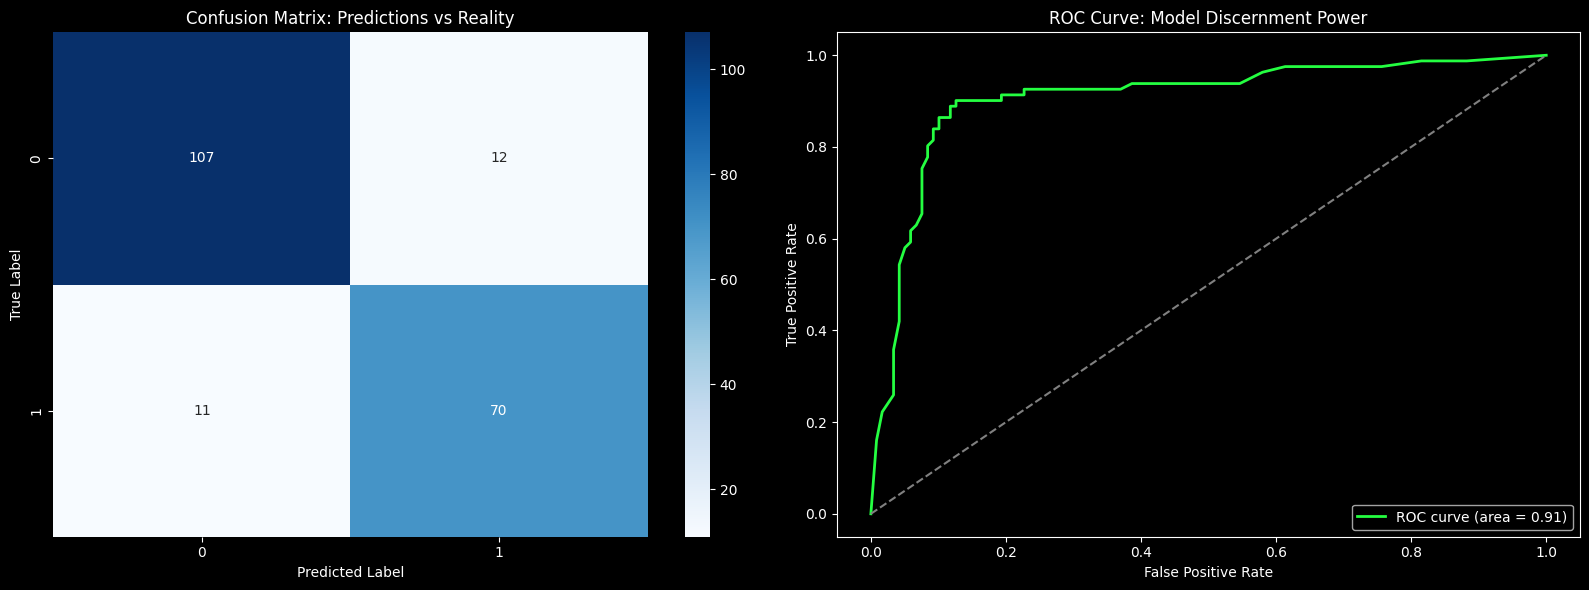

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

# --- STEP 1: Generate Synthetic Data for Prediction ---
np.random.seed(42)
n_samples = 1000

data = {
    'Age': np.random.randint(18, 70, n_samples),
    'Monthly_Income': np.random.uniform(2000, 10000, n_samples),
    'Time_Spent_On_Site': np.random.uniform(1, 60, n_samples),
    'Device_Type': np.random.choice([0, 1], n_samples), # 0: Mobile, 1: Desktop
}

df_ml = pd.DataFrame(data)

# Logic for Target: High income + High time spent = Likely to Purchase (1)
df_ml['Purchased'] = ((df_ml['Monthly_Income'] > 5000) & (df_ml['Time_Spent_On_Site'] > 20)).astype(int)
# Adding some noise to make it realistic
noise = np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
df_ml['Purchased'] = np.where(noise == 1, 1 - df_ml['Purchased'], df_ml['Purchased'])

# --- STEP 2: Train/Test Split ---
X = df_ml.drop('Purchased', axis=1)
y = df_ml['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 3: Build & Train the Model ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- STEP 4: Evaluate Performance ---
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)

print(f"MODEL TRAINING COMPLETE")
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("-" * 30)

# --- STEP 5: Visualizing Performance (Guaranteed Visibility) ---
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix: Predictions vs Reality')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='#24fe41', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax2.set_title('ROC Curve: Model Discernment Power')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()
